<a href="https://colab.research.google.com/github/ftyhanifah/Analisis-Deret-Waktu/blob/main/Tugas%202%20Praktikum%20ADW_STA1542_Minggu_2_Kecenderungan_Deret.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Nama: Fatiya Hanifah**

**NIM: M0501251053**

# Kecenderungan dalam Deret Waktu

Misalkan suatu deret waktu memiliki fungsi nilaitengah konstan. Model untuk deret waktu tersebut dapat dituliskan sebagai berikut:

$Y_t=\mu_t+X_t$

dengan $E(X_t)=0$ untuk semua $t$.

## Kecenderungan Linear

Deret dikatakan memiliki kecenderungan linear dalam waktu jika $\mu_t$ dapat dinyatakan sebagai:

$\mu_t=\beta_0+\beta_1t$

Berikut simulasi deret yang memiliki kecenderungan linear dalam waktu.

In [95]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import warnings

# Ignore all warnings
warnings.filterwarnings('ignore')

In [96]:
# membangkitkan data waktu dalam bentuk array (misalnya, 100 bulan)
np.random.seed(1053)
n=100
t = np.arange(n)

# Membuat deret dengan kecenderungan linear
beta1 = 0.5*53
beta0 = 10+53
deret = beta0 + beta1*t

# Menambahkan ingar acak
noise = np.random.normal(scale=2, size=n)  # Noise dengan standar deviasi 2
time_series = deret + noise  # Menggabungkan tren dengan noise

# Membuat DataFrame untuk menyimpan data
df = pd.DataFrame({"Time": pd.date_range(start="2017-01-01", periods=100, freq="M"),
                   "Value": time_series})


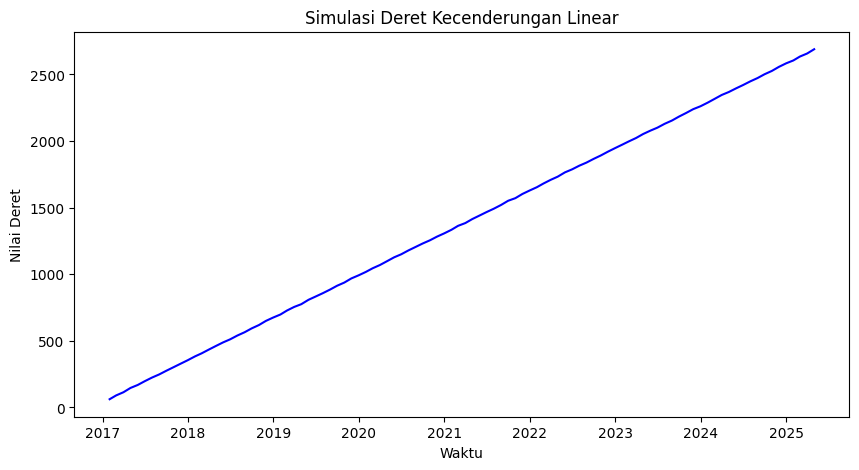

In [97]:
# Plot deret waktu dengan tren linear
plt.figure(figsize=(10, 5))
plt.plot(df["Time"], df["Value"], color="b")
plt.xlabel("Waktu")
plt.ylabel("Nilai Deret")
plt.title("Simulasi Deret Kecenderungan Linear")
plt.show()

Cek apakah ada korelasi antar pengamatan?

Nilai korelasi antara waktu dan nilai deret sebesar 1,0000 menunjukkan adanya hubungan linear positif yang sangat kuat. Artinya, semakin bertambah waktu, nilai deret cenderung semakin meningkat. Hal ini sesuai dengan data simulasi yang dibangkitkan menggunakan kecenderungan linear positif. Namun, korelasi tersebut merupakan korelasi antara waktu dan nilai deret, bukan secara langsung korelasi antar pengamatan pada lag tertentu.

In [98]:
# Konversi kolom Time menjadi angka (misalnya jumlah bulan sejak periode pertama)
df["Time_Numeric"] = (df["Time"].dt.to_period("M") - df["Time"].dt.to_period("M").min()).apply(lambda x: x.n)

# Hitung korelasi antara Time_Numeric dan Value
correlation = df["Time_Numeric"].corr(df["Value"])

print(f"Nilai korelasi antara Time dan Value: {correlation:.4f}")

Nilai korelasi antara Time dan Value: 1.0000


In [99]:
# Mendefinisikan variabel independen (X) dan dependen (Y)
X = df["Time_Numeric"]
Y = df["Value"]

#memanggil package statsmodels
import statsmodels.api as sm

# Tambahkan konstanta (intercept) ke model regresi
X = sm.add_constant(X)

# Buat dan jalankan model regresi
model = sm.OLS(Y, X).fit()

# menampilkan ringkasan hasil regresi
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                  Value   R-squared:                       1.000
Model:                            OLS   Adj. R-squared:                  1.000
Method:                 Least Squares   F-statistic:                 1.560e+07
Date:                Sat, 05 Sep 2026   Prob (F-statistic):          1.03e-256
Time:                        13:27:33   Log-Likelihood:                -206.99
No. Observations:                 100   AIC:                             418.0
Df Residuals:                      98   BIC:                             423.2
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const           63.3479      0.384    164.763   

Bagaimana hasil pengepasan model regresi dibandingkan dengan nilai parameter asli?

Apakah model regresi yang dipaskan sudah bagus?

Hasil pengepasan model regresi linear menunjukkan bahwa nilai parameter hasil estimasi sangat mendekati parameter asli yang digunakan dalam pembangkitan data. Parameter intercept yang diperoleh sebesar 63.3479 dan slope sebesar 26.5014, sedangkan parameter asli masing-masing adalah 63 dan 26.5. Perbedaan yang sangat kecil menunjukkan bahwa model regresi mampu mengestimasi pola trend dengan baik. Selain itu, nilai $(R^2)$ sebesar 1 menunjukkan bahwa hampir seluruh variasi data dapat dijelaskan oleh komponen waktu. Oleh karena itu, model regresi linear yang dipasang sudah sangat baik untuk menggambarkan kecenderungan linear pada data deret waktu tersebut.

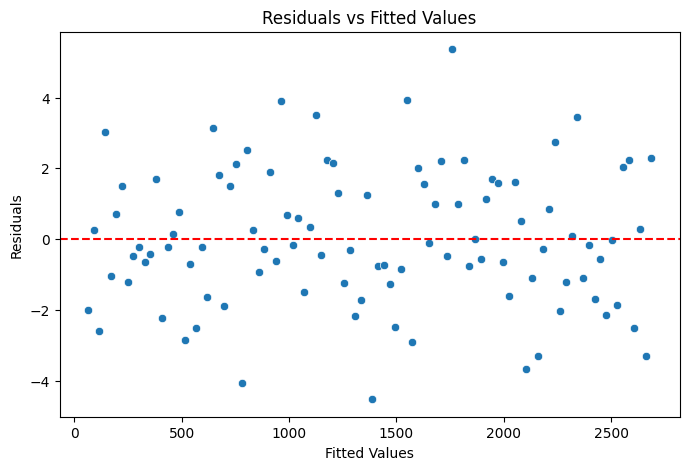

In [100]:
# Analisis Sisaan Model
import seaborn as sns

# Plot Residuals vs. Fitted Values
plt.figure(figsize=(8,5))
sns.scatterplot(x=model.fittedvalues, y=model.resid)
plt.axhline(y=0, color="r", linestyle="--")
plt.xlabel("Fitted Values")
plt.ylabel("Residuals")
plt.title("Residuals vs Fitted Values")
plt.show()


Apa interpretasi dari plot tersebut?

Berdasarkan plot residual terhadap fitted values, residual terlihat menyebar secara acak di sekitar garis nol dan tidak membentuk pola sistematis. Hal ini menunjukkan bahwa bentuk hubungan linear sudah cukup sesuai. Penyebaran residual juga tampak relatif konstan pada seluruh nilai fitted sehingga secara visual tidak terdapat indikasi kuat heteroskedastisitas.

In [101]:
from statsmodels.stats.diagnostic import het_breuschpagan

# Uji Breusch-Pagan
bp_test = het_breuschpagan(model.resid, model.model.exog)

print(f"P-value Breusch-Pagan Test: {bp_test[1]:.4f}")


P-value Breusch-Pagan Test: 0.4681


Apa kesimpulan dari nilai uji Breusch Pagan tersebut?

Berdasarkan uji Breusch-Pagan diperoleh nilai p-value sebesar 0.4681. Karena nilai tersebut lebih besar dari taraf signifikansi 5% (0.05), maka $(H_0)$ tidak ditolak. Dengan demikian, tidak terdapat indikasi heteroskedastisitas pada model regresi, sehingga residual memiliki varians yang relatif konstan dan asumsi homoskedastisitas terpenuhi

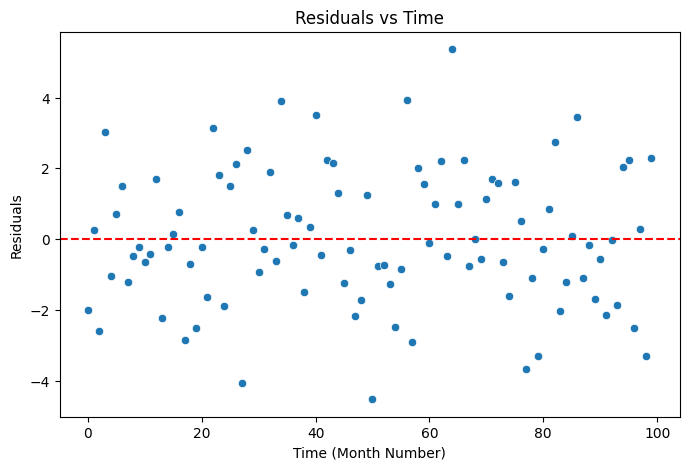

In [102]:
# Plot residual vs time
plt.figure(figsize=(8,5))
sns.scatterplot(x=df["Time_Numeric"], y=model.resid)
plt.axhline(y=0, color="red", linestyle="--")
plt.xlabel("Time (Month Number)")
plt.ylabel("Residuals")
plt.title("Residuals vs Time")
plt.show()


<Figure size 800x500 with 0 Axes>

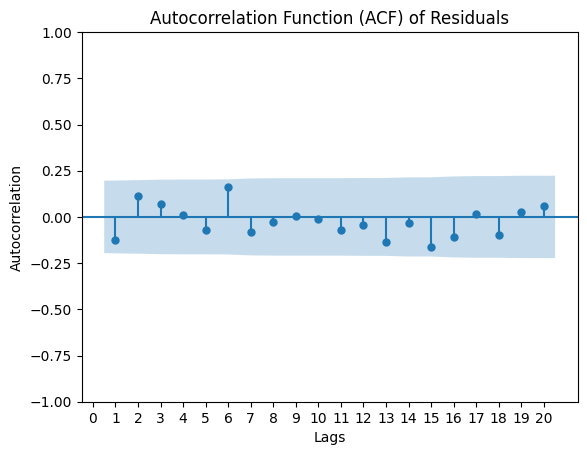

In [103]:
from statsmodels.graphics.tsaplots import plot_acf

# Plot Autocorrelation Function (ACF)
plt.figure(figsize=(8, 5))
plot_acf(model.resid, lags=20, zero=False)
plt.xticks(ticks=range(0, 21, 1))
plt.title("Autocorrelation Function (ACF) of Residuals")
plt.xlabel("Lags")
plt.ylabel("Autocorrelation")
plt.show()


Apa yang dapat Anda simpulkan dari plot di atas?

Plot residual terhadap waktu menunjukkan residual tersebar secara acak di sekitar garis nol tanpa pola tertentu. Selain itu, hasil ACF residual menunjukkan tidak adanya autokorelasi yang signifikan karena seluruh nilai ACF berada dalam batas kepercayaan. Dengan demikian, residual model dapat dianggap bersifat acak dan model regresi linear sudah cukup baik dalam menjelaskan kecenderungan linear pada data.

In [10]:
from statsmodels.stats.diagnostic import acorr_ljungbox

# Uji Ljung-Box untuk autokorelasi residual
ljung_box_test = acorr_ljungbox(model.resid, lags=range(1,20), return_df=True)

print("Ljung-Box Test p-value:")
print(ljung_box_test)


Ljung-Box Test p-value:
      lb_stat  lb_pvalue
1    1.623524   0.202601
2    2.941076   0.229802
3    3.454922   0.326656
4    3.463542   0.483443
5    3.966319   0.554275
6    6.769581   0.342683
7    7.534859   0.375388
8    7.616148   0.471834
9    7.617550   0.573099
10   7.631249   0.664806
11   8.247857   0.690944
12   8.487309   0.745984
13  10.599522   0.644327
14  10.722152   0.707712
15  13.893387   0.533630
16  15.294828   0.503160
17  15.317128   0.572651
18  16.529124   0.555671
19  16.622404   0.615432


Apa kesimpulan dari hasil uji Ljung-Box tersebut?

Berdasarkan hasil uji Ljung-Box, seluruh nilai p-value pada berbagai lag lebih besar dari taraf signifikansi 5%. Oleh karena itu, $(H_0)$ tidak ditolak, sehingga tidak terdapat bukti adanya autokorelasi yang signifikan pada residual. Dengan demikian, residual dapat dianggap bersifat acak dan model regresi linear telah mampu menangkap pola kecenderungan linear pada data dengan baik.

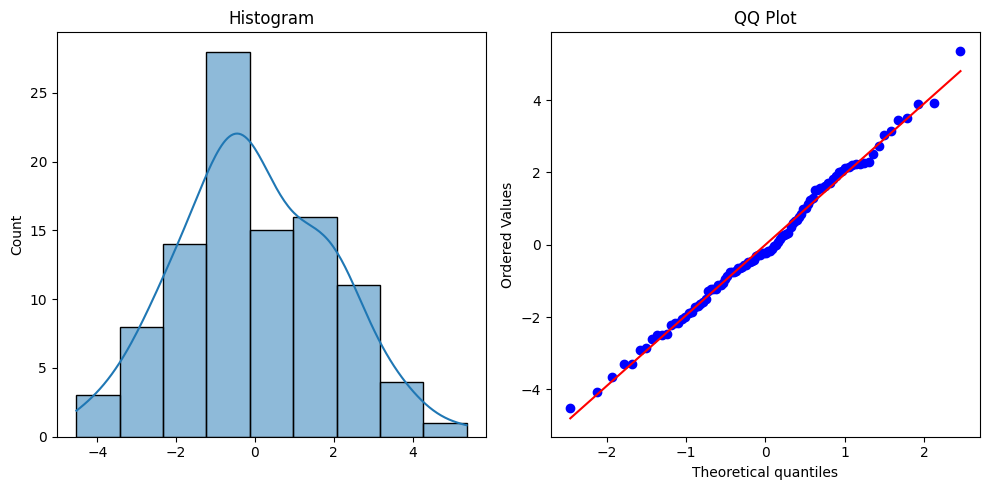

In [104]:
# Histogram Residuals
import scipy.stats as stats
fig, axes = plt.subplots(1, 2, figsize=(10,5))
# Histogram
sns.histplot(model.resid, kde=True, ax=axes[0])
axes[0].set_title('Histogram')

# QQ Plot
stats.probplot(model.resid, dist="norm", plot=axes[1])
axes[1].set_title('QQ Plot')

plt.tight_layout()
plt.show()

Apa kesimpulan Anda berdasarkan plot di atas?

Residual model regresi dapat dianggap mengikuti distribusi normal. Histogram menunjukkan pola distribusi yang mendekati bentuk lonceng dengan pusat di sekitar nol, sedangkan Q-Q Plot menunjukkan sebagian besar titik berada di sekitar garis diagonal. Dengan demikian, asumsi normalitas residual pada model regresi linear telah terpenuhi.

In [105]:
# Uji Shapiro-Wilk
shapiro_stat, shapiro_p_value = stats.shapiro(model.resid)
print(f"Shapiro-Wilk Test: Statistics = {shapiro_stat}, p-value = {shapiro_p_value}")

Shapiro-Wilk Test: Statistics = 0.9933556888263806, p-value = 0.9085624949027984


Apakah kesimpulan Anda dari nilai uji Shapiro Wilk sama dengan kesimpulan Anda berdasarkan plot?

Berdasarkan uji Shapiro-Wilk diperoleh p-value sebesar 0,9086, yang lebih besar dari taraf signifikansi 5% (0,05). Oleh karena itu, $(H_0)$ tidak ditolak sehingga tidak terdapat bukti yang cukup untuk menyatakan bahwa residual tidak berdistribusi normal. Hasil ini konsisten dengan histogram yang menunjukkan bentuk distribusi mendekati normal dan QQ Plot yang memperlihatkan sebagian besar titik berada di sekitar garis diagonal. Dengan demikian, asumsi normalitas residual dapat dianggap terpenuhi.

## Kecenderungan Kuadratik

Deret dikatakan memiliki kecenderungan kuadratik dalam waktu jika $\mu_t$ dapat dinyatakan sebagai:

$\mu_t=\beta_0+\beta_1t+\beta_2t^2$


In [107]:
# Menentukan parameter simulasi
np.random.seed(1053)
n_periods = 120
beta_0, beta_1, beta_2= 50+53, 0.5*53, 0.02*53
noise = np.random.normal(0, 10, n_periods)
time = np.arange(n_periods)

# Membuat komponen kuadratik
quadratic_component = beta_0 + beta_1 * time + beta_2 * time**2

# Menambahkan noise untuk membuat data lebih realistis
data = quadratic_component + noise

# Membuat DataFrame
dates = pd.date_range(start='2010-01-01', periods=n_periods, freq='M')
df_quad = pd.DataFrame({'Date': dates, 'Value': data})

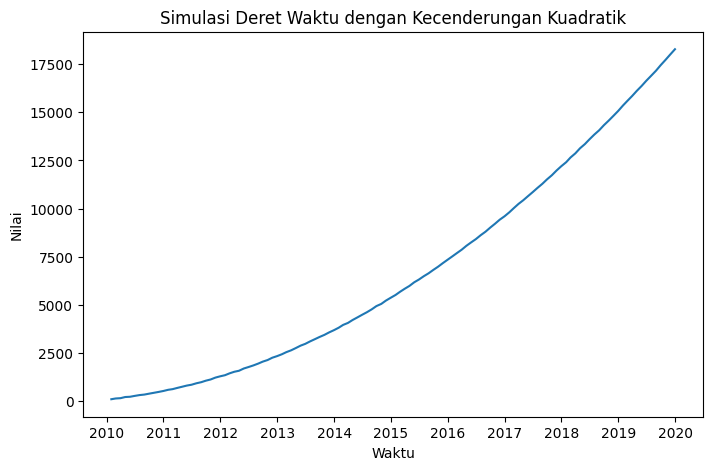

In [108]:
# Plot hasil simulasi deret waktu dengan kecenderungan kuadratik
plt.figure(figsize=(8, 5))
plt.plot(df_quad.Date, df_quad['Value'])
plt.title('Simulasi Deret Waktu dengan Kecenderungan Kuadratik')
plt.xlabel('Waktu')
plt.ylabel('Nilai')
plt.show()

Apa interpretasi Anda terhadap deret? Apa perbedaan pola yang terlihat dalam deret dibandingkan plot deret pada pola kecenderungan linear?

Berdasarkan plot simulasi deret waktu dengan kecenderungan kuadratik, terlihat bahwa nilai deret mengalami peningkatan dengan laju perubahan yang semakin besar sepanjang waktu. Pada awal periode peningkatan masih relatif lambat, tetapi semakin lama nilai deret meningkat semakin cepat sehingga membentuk pola melengkung. Hal ini berbeda dengan kecenderungan linear yang memiliki pola peningkatan konstan dan membentuk garis lurus. Pada kecenderungan kuadratik, perubahan nilai tidak konstan karena dipengaruhi oleh komponen $(t^2)$, sehingga menghasilkan trend yang semakin meningkat (accelerating trend).

In [109]:
# Mendefinisikan variabel independen (X) dan dependen (Y)
X = np.column_stack((time, time**2))
X = sm.add_constant(X)
Y = data


# Buat dan jalankan model regresi
model_quad = sm.OLS(Y, X).fit()

# menampilkan ringkasan hasil regresi
print(model_quad.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       1.000
Model:                            OLS   Adj. R-squared:                  1.000
Method:                 Least Squares   F-statistic:                 1.917e+07
Date:                Sat, 05 Sep 2026   Prob (F-statistic):          1.98e-323
Time:                        13:40:10   Log-Likelihood:                -439.76
No. Observations:                 120   AIC:                             885.5
Df Residuals:                     117   BIC:                             893.9
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        103.3376      2.577     40.098      0.0

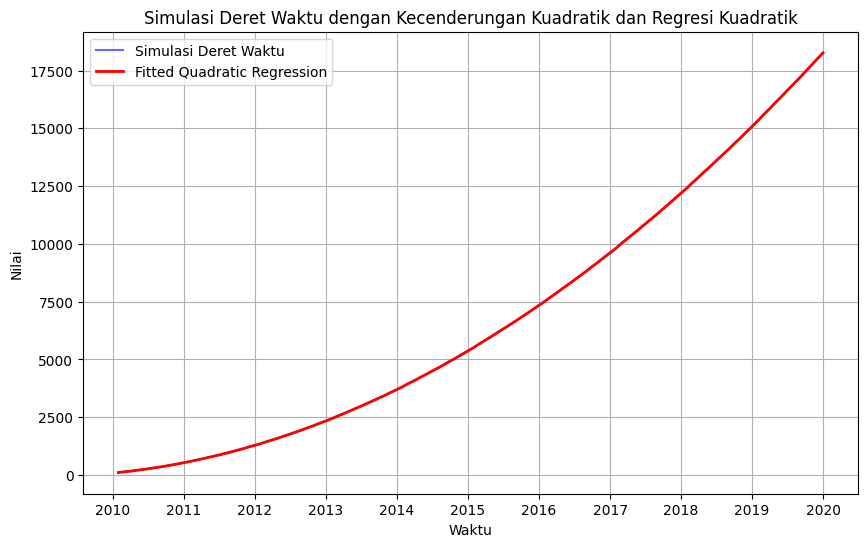

In [110]:
# Prediksi menggunakan model yang sudah dilatih
data_pred = model_quad.predict(X)

# Plot hasil simulasi deret waktu dan regresi kuadratik
plt.figure(figsize=(10, 6))
plt.plot(df_quad.Date, df_quad['Value'], label='Simulasi Deret Waktu', color='blue', alpha=0.6)
plt.plot(df_quad.Date, data_pred, label='Fitted Quadratic Regression', color='red', linewidth=2)
plt.title('Simulasi Deret Waktu dengan Kecenderungan Kuadratik dan Regresi Kuadratik')
plt.xlabel('Waktu')
plt.ylabel('Nilai')
plt.legend()
plt.grid(True)
plt.show()

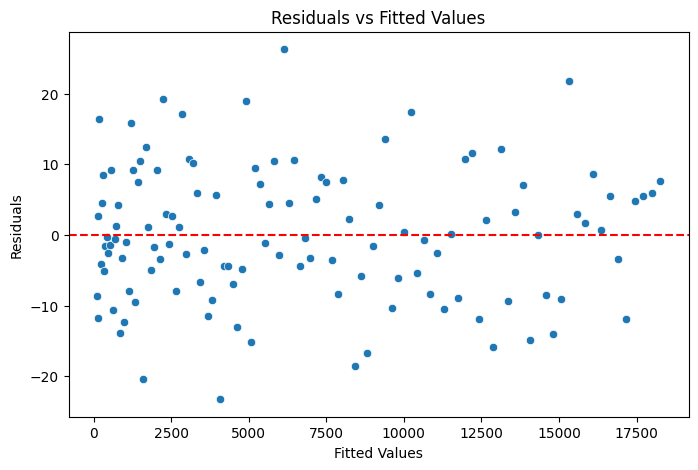

In [111]:
# Analisis Sisaan Model Kuadratik
import seaborn as sns

plt.figure(figsize=(8,5))
sns.scatterplot(x=model_quad.fittedvalues, y=model_quad.resid)

plt.axhline(y=0, color="red", linestyle="--")
plt.xlabel("Fitted Values")
plt.ylabel("Residuals")
plt.title("Residuals vs Fitted Values")
plt.show()

Berdasarkan plot residual terhadap fitted values, residual terlihat menyebar secara acak di sekitar garis nol dan tidak membentuk pola tertentu. Penyebaran residual juga relatif konstan pada berbagai nilai fitted. Hal ini menunjukkan bahwa bentuk model kuadratik sudah cukup sesuai dan secara visual tidak terdapat indikasi kuat heteroskedastisitas.

In [112]:
from statsmodels.stats.diagnostic import het_breuschpagan

bp_test_quad = het_breuschpagan(
    model_quad.resid,
    model_quad.model.exog
)

print("Breusch-Pagan:")
print("LM Statistic =", bp_test_quad[0])
print("LM p-value =", bp_test_quad[1])
print("F Statistic =", bp_test_quad[2])
print("F p-value =", bp_test_quad[3])

Breusch-Pagan:
LM Statistic = 1.5569429941300106
LM p-value = 0.45910722200370724
F Statistic = 0.7689869500083224
F p-value = 0.46581039107172884


Berdasarkan uji Breusch-Pagan diperoleh LM p-value sebesar 0,4591 dan F p-value sebesar 0,4658. Kedua nilai tersebut lebih besar dari taraf signifikansi 5%, sehingga \(H_0\) tidak ditolak. Dengan demikian, tidak terdapat indikasi heteroskedastisitas dan varians residual dapat dianggap relatif konstan. Oleh karena itu, asumsi homoskedastisitas terpenuhi.

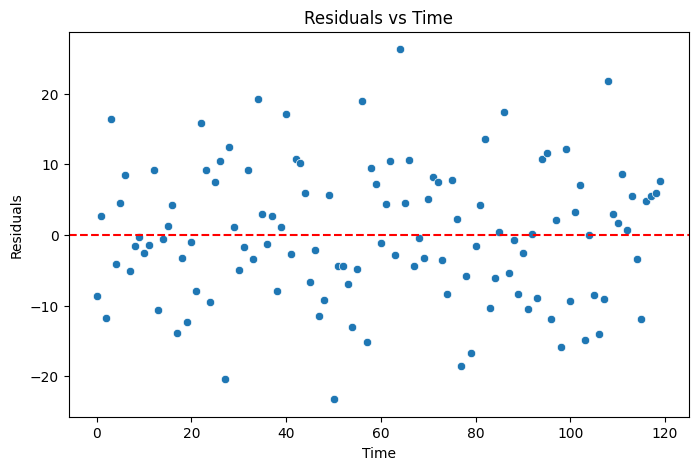

In [113]:
plt.figure(figsize=(8,5))
sns.scatterplot(x=time, y=model_quad.resid)

plt.axhline(y=0, color="red", linestyle="--")
plt.xlabel("Time")
plt.ylabel("Residuals")
plt.title("Residuals vs Time")
plt.show()

Berdasarkan plot residual terhadap waktu, residual terlihat tersebar secara acak di sekitar garis nol dan tidak menunjukkan pola naik, turun, maupun pola sistematis lainnya sepanjang waktu. Hal ini menunjukkan bahwa setelah kecenderungan kuadratik dimodelkan, tidak terlihat pola waktu yang kuat yang masih tertinggal pada residual.

<Figure size 800x500 with 0 Axes>

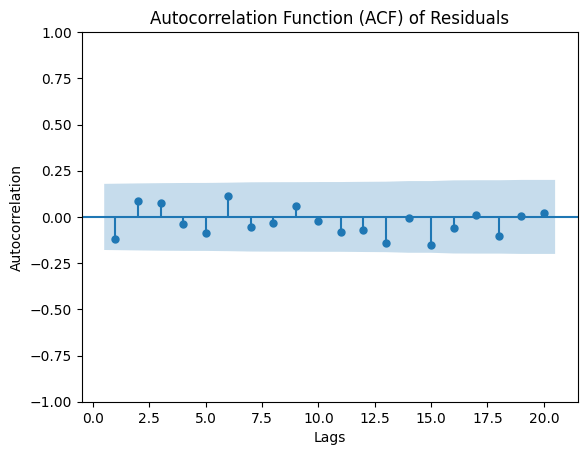

In [114]:
from statsmodels.graphics.tsaplots import plot_acf

plt.figure(figsize=(8,5))
plot_acf(model_quad.resid, lags=20, zero=False)

plt.title("Autocorrelation Function (ACF) of Residuals")
plt.xlabel("Lags")
plt.ylabel("Autocorrelation")
plt.show()

Berdasarkan plot ACF residual, seluruh nilai autokorelasi pada lag yang diamati berada di dalam batas kepercayaan. Hal ini menunjukkan bahwa secara visual tidak terdapat autokorelasi residual yang signifikan.

In [115]:
from statsmodels.stats.diagnostic import acorr_ljungbox

ljung_box_quad = acorr_ljungbox(
    model_quad.resid,
    lags=[12],
    return_df=True
)

print("Ljung-Box:")
print(ljung_box_quad)

Ljung-Box:
     lb_stat  lb_pvalue
12  8.682764   0.729761


Berdasarkan uji Ljung-Box pada lag 12 diperoleh p-value sebesar 0,7298. Karena nilai tersebut lebih besar dari 0,05, maka \(H_0\) tidak ditolak. Dengan demikian, tidak terdapat bukti yang cukup untuk menyatakan adanya autokorelasi residual sampai lag 12, sehingga asumsi independensi residual dapat dianggap terpenuhi.

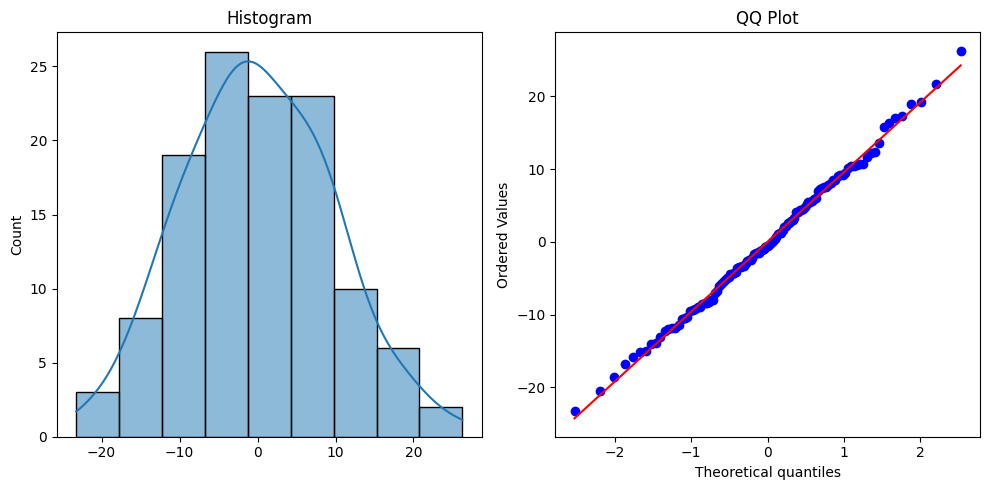

In [116]:
import scipy.stats as stats

fig, axes = plt.subplots(1, 2, figsize=(10,5))

# Histogram
sns.histplot(model_quad.resid, kde=True, ax=axes[0])
axes[0].set_title("Histogram")

# QQ Plot
stats.probplot(model_quad.resid, dist="norm", plot=axes[1])
axes[1].set_title("QQ Plot")

plt.tight_layout()
plt.show()

Histogram residual menunjukkan bentuk yang relatif simetris dan menyerupai distribusi normal. Pada QQ Plot, sebagian besar titik berada di sekitar garis diagonal, sehingga secara visual residual dapat dianggap mendekati distribusi normal.

In [117]:
shapiro_stat_quad, shapiro_p_quad = stats.shapiro(model_quad.resid)

print("Shapiro-Wilk:")
print("Statistic =", shapiro_stat_quad)
print("p-value =", shapiro_p_quad)

Shapiro-Wilk:
Statistic = 0.9963970715669855
p-value = 0.9911838590036198


Berdasarkan uji Shapiro-Wilk diperoleh p-value sebesar 0,9912 yang lebih besar dari taraf signifikansi 5%. Oleh karena itu, \(H_0\) tidak ditolak sehingga tidak terdapat bukti yang cukup untuk menyatakan bahwa residual tidak berdistribusi normal. Hasil ini konsisten dengan histogram dan QQ Plot. Dengan demikian, asumsi normalitas residual dapat dianggap terpenuhi.

Cek apakah model regresi kuadratik yang dipaskan terhadap sudah memenuhi asumsi-asumsi model!

Apakah model yang dipaskan terhadap deret sudah tepat? Jelaskan jawaban Anda!

**Jawab:**

Berdasarkan hasil pengepasan model regresi kuadratik, diperoleh estimasi parameter $(\hat{\beta}_0=103.3376)$, $(\hat{\beta}_1=26.5816)$, dan $(\hat{\beta}_2=1.0593)$. Nilai tersebut sangat dekat dengan parameter asli yang digunakan dalam pembangkitan data, yaitu $(\beta_0=103)$, $(\beta_1=26.5)$, dan $(\beta_2=1.06)$. Selain itu, nilai $(R^2=1.000)$ menunjukkan bahwa hampir seluruh variasi deret dapat dijelaskan oleh model kuadratik, dan seluruh koefisien memiliki p-value kurang dari 0,05. Plot hasil fitting juga menunjukkan bahwa kurva regresi hampir berhimpit dengan deret simulasi.

Pemeriksaan residual menunjukkan bahwa asumsi model secara umum terpenuhi. Uji Breusch-Pagan menghasilkan p-value sebesar 0,4591 (>0,05), sehingga tidak terdapat indikasi heteroskedastisitas. Uji Ljung-Box pada lag 12 menghasilkan p-value sebesar 0,7298 (>0,05), sehingga tidak terdapat bukti adanya autokorelasi residual. Uji Shapiro-Wilk menghasilkan p-value sebesar 0,9912 (>0,05), sehingga residual dapat dianggap berdistribusi normal. Hasil tersebut juga didukung oleh plot residual, ACF, histogram, QQ Plot, serta nilai Durbin-Watson sebesar 2,223 yang mendekati 2.

Dengan demikian, asumsi normalitas, homoskedastisitas, dan independensi residual dapat dianggap terpenuhi. Model regresi kuadratik yang dipasang sudah tepat untuk menggambarkan deret simulasi karena mampu menangkap pola peningkatan yang semakin cepat melalui komponen $(t^2)$.

In [ ]:
# cek asumsi model regresi kuadratik

## Kecenderungan Musiman/Siklik

Misalkan suatu deret waktu memiliki nilaitengah $\mu_t$ yang didefinisikan sebagai berikut:

$\mu_t=\beta_0+\beta_1 cos(2\pi f t)+\beta_2 sin(2\pi ft)$

Deret tersebut memiliki kecenderungan kosinus yang berpola musiman.

Bentuk lain fungsi nilaitengah dari kecenderungan musiman (misalnya untuk data bulanan) adalah $\mu_t$ berupa suatu konstanta sejumlah 12 yang nilai berbeda-beda. Nilai ini diinterpretasikan sebagai nilai harapan rata-rata data untuk masing-masing bulan, atau dapat dituliskan sebagai berikut:

$\mu_t=\beta_1$ , untuk $t=1,13,25,...$
       
$\mu_t=\beta_2$ , untuk $t=2,14,26,...$

$.$

$.$

$.$

$\mu_t=\beta_{12}$ , $untuk t=12,24,36,...$


In [118]:
# Menentukan parameter simulasi
np.random.seed(1053)
n_periods = 120
beta0, beta1, beta2=50+53,-25*53, -2*53
freq=1/12

# Membuat komponen musiman
time = np.arange(n_periods)
seasonal_component = beta0+ beta1*np.cos(2*np.pi*time*freq)+beta2*np.sin(2*np.pi*time*freq)

# Menambahkan noise acak
noise = np.random.normal(0, 2, n_periods)

# Simulasi data dengan hanya komponen musiman dan noise (tanpa tren)
data = seasonal_component + noise

# Membuat index waktu (misalnya menggunakan bulan)
dates = pd.date_range(start='2010-01-01', periods=n_periods, freq='M')

# Membuat DataFrame untuk mempermudah analisis dan visualisasi
df_seasonal = pd.DataFrame({'Date': dates, 'Value': data})


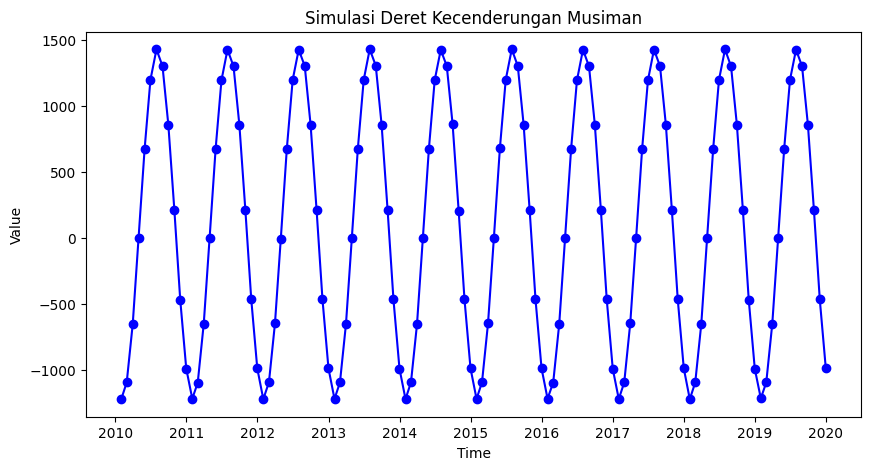

In [119]:
# Plot data deret waktu
plt.figure(figsize=(10, 5))
plt.plot(df_seasonal["Date"], df_seasonal["Value"],'-ob')
plt.xlabel("Time")
plt.ylabel("Value")
plt.title("Simulasi Deret Kecenderungan Musiman")
plt.show()


Misalkan deret tersebut merupakan deret musiman dengan periode musiman 12. Bagaimana Anda menginterpretasikan pola yang terlihat dalam deret tersebut?

Grafik Simulasi Deret Kecenderungan Musiman dibangkitkan menggunakan fungsi:

$$ \mu_t=\beta_0+\beta_1\cos(2\pi ft)+\beta_2\sin(2\pi ft) $$

dengan:

$$ f=\frac{1}{12} $$

yang berarti pola akan berulang setiap 12 periode (12 bulan).

Berdasarkan plot deret waktu, terlihat adanya pola naik dan turun yang berulang secara teratur setiap 12 periode. Hal ini menunjukkan adanya pola musiman dengan periode 12 bulan. Deret tidak menunjukkan kecenderungan meningkat atau menurun dalam jangka panjang, melainkan berfluktuasi di sekitar level rata-rata yang relatif tetap, yaitu sekitar $(\beta_0=103)$. Besarnya nilai maksimum dan minimum relatif serupa pada setiap siklus, sedangkan sedikit perbedaan antarsiklus disebabkan oleh noise acak. Dengan demikian, pola utama pada deret adalah pola musiman tahunan tanpa adanya trend.

In [121]:
# membuat dummy variabel musiman dalam data
from statsmodels.tsa.deterministic import Seasonality
musim= Seasonality(12, initial_period=1).in_sample(df_seasonal.index)
musim.columns=['Januari','Februari','Maret','April','Mei','Juni','Juli','Agustus','September','Oktober','November','Desember']

In [49]:
musim

,Januari,Februari,Maret,April,Mei,Juni,Juli,Agustus,September,Oktober,November,Desember
0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...
115,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
116,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
117,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
118,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0


In [122]:
# pengepasan model regresi tanpa intercept
musiman=sm.OLS(df_seasonal["Value"],musim).fit()

In [123]:
print(musiman.summary())

                            OLS Regression Results                            
Dep. Variable:                  Value   R-squared:                       1.000
Model:                            OLS   Adj. R-squared:                  1.000
Method:                 Least Squares   F-statistic:                 2.853e+06
Date:                Sat, 05 Sep 2026   Prob (F-statistic):          1.45e-289
Time:                        14:02:05   Log-Likelihood:                -236.97
No. Observations:                 120   AIC:                             497.9
Df Residuals:                     108   BIC:                             531.4
Df Model:                          11                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Januari    -1221.8007      0.581  -2102.447      0.0

Bagaimana interpretasi dari hasil tersebut?

Berdasarkan hasil regresi musiman tanpa intersep, setiap koefisien menunjukkan estimasi rata-rata nilai deret untuk masing-masing bulan. Nilai rata-rata tertinggi terjadi pada bulan Juli sebesar sekitar 1428,47, diikuti Agustus sebesar 1302,43 dan Juni sebesar 1197,24. Sementara itu, nilai terendah terjadi pada Januari sebesar sekitar -1221,80, Februari sebesar -1096,82, dan Desember sebesar -990,81. Perbedaan nilai antarbulan tersebut menunjukkan pola musiman yang jelas dan konsisten dengan pola sinusoidal pada data simulasi. Nilai $(R^2=1.000)$ menunjukkan bahwa model dummy musiman mampu menjelaskan hampir seluruh variasi deret. Nilai Durbin-Watson sebesar 2,077 juga memberikan indikasi awal bahwa residual tidak mengalami autokorelasi yang kuat, sedangkan p-value Jarque-Bera sebesar 0,835 menunjukkan bahwa residual dapat dianggap berdistribusi normal.



In [124]:
# Analisis Sisaan
# mendapatkan sisaan terbakukan
influence=musiman.get_influence()
std_resid=influence.resid_studentized_internal

mapping={1:'$J$',2:'$F$',3:'$M$',
 4:'$A$',5:'$M$',6:'$J$',
 7:'$J$',8:'$A$',9:'$S$',
 10:'$O$',11:'$N$',12:'$D$'}

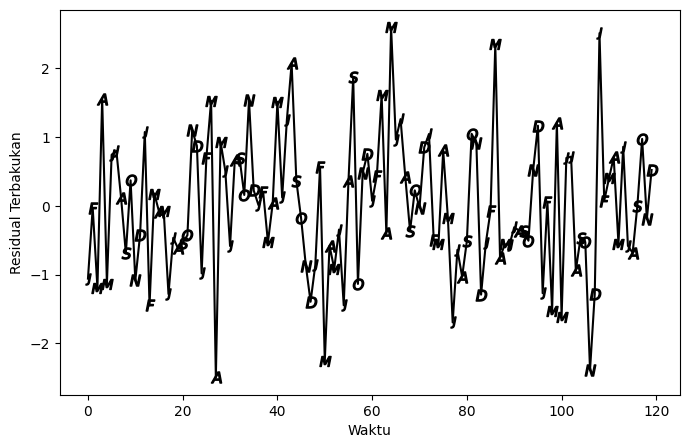

In [125]:
#memetakan sisaan dengan bentuk plot sesuai simbol bulan/musim
plt.figure(figsize=(8,5))
for i in range(len(std_resid)):
 plt.plot(i, std_resid[i], marker=mapping[i%12+1],
 color='black', markersize=8)

#membuat plot sisaan terbakukan
plt.plot(std_resid, color='black')
plt.xlabel('Waktu'), plt.ylabel('Residual Terbakukan')
plt.show()


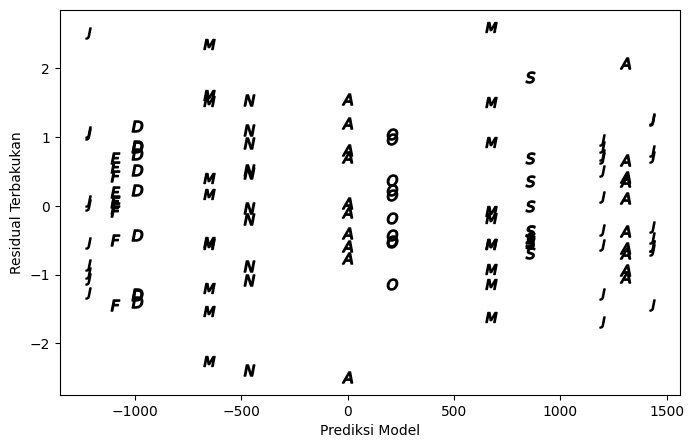

In [126]:
# membuat plot fittedvalues dengan residual terbakukan dengan simbol bulan
plt.figure(figsize=(8,5))
for i in range(len(std_resid)):
  plt.plot(musiman.fittedvalues.values[i],
           std_resid[i], marker=mapping[i%12+1],
           color='black', markersize=8)
plt.xlabel('Prediksi Model'),plt.ylabel('Residual Terbakukan')
plt.show()

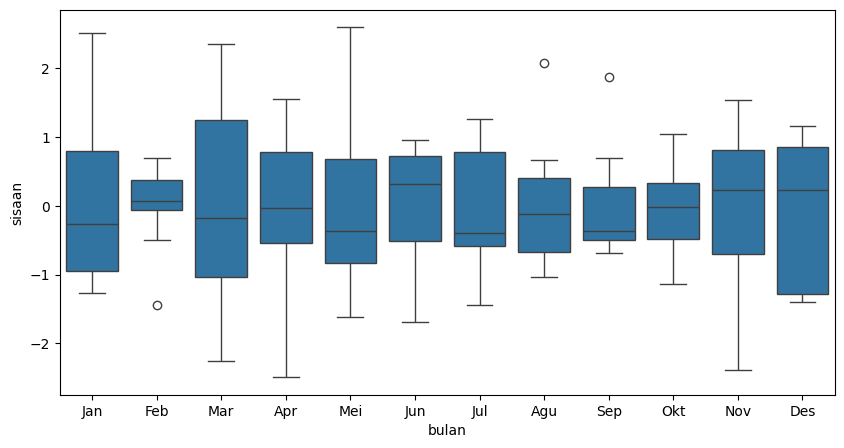

In [127]:
#membuat list daftar bulan
bulan=['Jan','Feb','Mar','Apr','Mei','Jun','Jul','Agu','Sep','Okt','Nov','Des']*10

#membuat dataframe untuk mengidentifikasi sisaan dan periode bulannya
box_sisaan=pd.DataFrame(zip(bulan[:-1], std_resid),
columns=['bulan','sisaan'])

#membuat boxplot per buln
plt.figure(figsize=(10,5))
sns.boxplot(x='bulan',y='sisaan',data=box_sisaan)
plt.show()

Bagaimana interpretasi Anda terhadap tiga plot di atas?

Berdasarkan plot sisaan terbakukan terhadap waktu, residual terlihat berfluktuasi secara acak di sekitar nol dan tidak menunjukkan pola trend maupun pola musiman yang masih tersisa. Hal ini menunjukkan bahwa pola musiman utama telah cukup baik ditangkap oleh model.

Pada plot residual terbakukan terhadap nilai prediksi, terlihat beberapa kelompok vertikal. Pengelompokan tersebut merupakan hal yang wajar karena model dummy musiman memberikan nilai fitted yang sama untuk seluruh pengamatan yang berasal dari bulan yang sama. Di dalam masing-masing kelompok, residual tetap tersebar di sekitar nol dan tidak menunjukkan pola sistematis yang jelas.

Boxplot residual berdasarkan bulan menunjukkan bahwa residual pada setiap bulan secara umum berada di sekitar nol. Median tidak harus tepat nol, tetapi karena model mengestimasi rata-rata setiap bulan, rata-rata residual untuk masing-masing kelompok bulan akan mendekati nol. Terdapat beberapa residual yang relatif ekstrem pada beberapa bulan, tetapi tidak terlihat adanya pola penyimpangan sistematis yang sama pada bulan tertentu.

Secara keseluruhan, ketiga plot menunjukkan bahwa model telah cukup baik dalam menangkap pola musiman pada deret karena tidak terlihat struktur waktu atau pola musiman yang kuat yang masih tersisa pada residual.

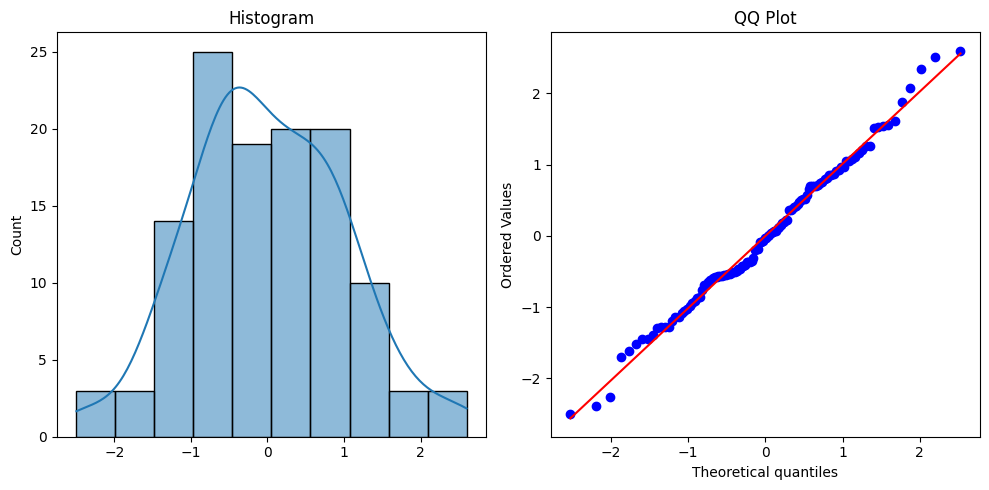

In [129]:
# Histogram Residuals
import scipy.stats as stats
fig, axes = plt.subplots(1, 2, figsize=(10,5))
# Histogram
sns.histplot(std_resid, kde=True, ax=axes[0])
axes[0].set_title('Histogram')

# QQ Plot
stats.probplot(std_resid, dist="norm", plot=axes[1])
axes[1].set_title('QQ Plot')

plt.tight_layout()
plt.show()

Berdasarkan plot-plot tersebut apakah dapat dikatakan bahwa model yang dipaskan sudah tepat?

Hitunglah statistik uji untuk mengecek asumsi model

Berdasarkan histogram, bentuk distribusi residual terlihat relatif simetris dan mendekati bentuk distribusi normal. Pada QQ Plot, sebagian besar titik residual juga berada di sekitar garis diagonal, sehingga secara visual asumsi normalitas residual cukup terpenuhi. Hasil plot diagnostik sebelumnya juga menunjukkan bahwa residual cenderung menyebar di sekitar nol tanpa pola waktu maupun pola sistematis yang jelas. Dengan demikian, secara visual model musiman tampak cukup baik dalam menangkap pola deret. Namun, kesimpulan mengenai terpenuhinya asumsi model perlu dikonfirmasi menggunakan uji statistik, yaitu Shapiro-Wilk, Breusch-Pagan, dan Ljung-Box.

In [ ]:
# hitung statistik uji untuk mengecek asumsi model tanpa intersep

In [130]:
from scipy import stats
from statsmodels.stats.diagnostic import het_breuschpagan, acorr_ljungbox
import statsmodels.api as sm

# ====================================================
# 1. UJI NORMALITAS SHAPIRO-WILK
# residual tetap dari MODEL TANPA INTERSEP
# ====================================================

shapiro_stat, shapiro_p = stats.shapiro(musiman.resid)

print("Shapiro-Wilk:")
print("Statistic =", shapiro_stat)
print("p-value =", shapiro_p)


# ====================================================
# 2. UJI HOMOSKEDASTISITAS BREUSCH-PAGAN
# residual tetap dari MODEL TANPA INTERSEP
# tetapi matriks X dibuat ekuivalen:
# konstanta + 11 dummy bulan
# ====================================================

X_bp = sm.add_constant(musim.iloc[:, 1:])

bp_test = het_breuschpagan(musiman.resid, X_bp)

print("\nBreusch-Pagan:")
print("LM Statistic =", bp_test[0])
print("LM p-value =", bp_test[1])
print("F Statistic =", bp_test[2])
print("F p-value =", bp_test[3])


# ====================================================
# 3. UJI AUTOKORELASI LJUNG-BOX
# ====================================================

ljung_box = acorr_ljungbox(
    musiman.resid,
    lags=[12],
    return_df=True
)

print("\nLjung-Box:")
print(ljung_box)

Shapiro-Wilk:
Statistic = 0.9914762323416081
p-value = 0.6714820831052319

Breusch-Pagan:
LM Statistic = 13.376624025308992
LM p-value = 0.2694236175525043
F Statistic = 1.2317573477050414
F p-value = 0.27505073091216925

Ljung-Box:
      lb_stat  lb_pvalue
12  20.120848   0.064834


Berdasarkan hasil pengujian asumsi model musiman tanpa intersep, ketiga uji memberikan hasil yang mendukung bahwa model sudah cukup baik.

Untuk uji Shapiro-Wilk, diperoleh statistik sebesar 0.9915 dengan p-value 0.6715. Karena p-value > 0.05, maka gagal menolak $H_0$.

Berdasarkan uji Shapiro-Wilk, tidak terdapat bukti yang cukup untuk menyatakan bahwa residual tidak berdistribusi normal. Dengan demikian, asumsi normalitas residual dapat dianggap terpenuhi. Hasil ini konsisten dengan histogram dan QQ Plot yang menunjukkan pola residual mendekati distribusi normal.

Untuk uji Breusch-Pagan, diperoleh LM p-value 0.2694 dan F p-value 0.2751. Keduanya lebih besar dari 0.05, sehingga gagal menolak $H_0$.

Berdasarkan uji Breusch-Pagan, tidak terdapat bukti adanya heteroskedastisitas pada residual. Dengan demikian, varians residual dapat dianggap relatif konstan dan asumsi homoskedastisitas terpenuhi.

Untuk uji Ljung-Box pada lag 12, diperoleh p-value sebesar 0.0648. Karena:

$$ 0.0648 > 0.05 $$

maka pada taraf signifikansi 5% gagal menolak $H_0$.

Berdasarkan uji Ljung-Box pada lag 12, tidak terdapat bukti yang cukup untuk menyatakan adanya autokorelasi residual hingga lag 12. Dengan demikian, pada taraf signifikansi 5%, asumsi independensi residual dapat dianggap terpenuhi.

**Kesimpulan Akhir**

Berdasarkan pemeriksaan visual dan hasil pengujian statistik, model regresi musiman tanpa intersep secara umum telah memenuhi asumsi regresi. Residual dapat dianggap berdistribusi normal berdasarkan uji Shapiro-Wilk dengan p-value 0.6715, memiliki varians yang relatif konstan berdasarkan uji Breusch-Pagan dengan p-value 0.2694, serta tidak menunjukkan autokorelasi yang signifikan hingga lag 12 berdasarkan uji Ljung-Box dengan p-value 0.0648. Dengan demikian, tidak terdapat indikasi pelanggaran asumsi model pada taraf signifikansi 5%, sehingga model musiman yang dipasang dapat dianggap cukup sesuai untuk menggambarkan pola musiman pada deret.

In [131]:
# pengepasan model regresi dengan intersep
musiman_int=sm.OLS(df_seasonal["Value"],sm.add_constant(musim.iloc[:,1:])).fit()

In [132]:
print(musiman_int.summary())

                            OLS Regression Results                            
Dep. Variable:                  Value   R-squared:                       1.000
Model:                            OLS   Adj. R-squared:                  1.000
Method:                 Least Squares   F-statistic:                 2.853e+06
Date:                Sat, 05 Sep 2026   Prob (F-statistic):          1.45e-289
Time:                        14:17:46   Log-Likelihood:                -236.97
No. Observations:                 120   AIC:                             497.9
Df Residuals:                     108   BIC:                             531.4
Df Model:                          11                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const      -1221.8007      0.581  -2102.447      0.0

Perhatikan hasil pengepasan model dengan intersep. Bandingkan hasilnya dengan pengepasan tanpa intersep. Bagaimana interpretasi model dengan intersep dibandingkan model tanpa intersep? Jelaskan cara memaknai nilai koefisien regresi yang diperoleh!

Pada model tanpa intersep, setiap koefisien dummy bulan secara langsung menunjukkan rata-rata nilai deret pada bulan tersebut. Sebaliknya, pada model dengan intersep, Januari digunakan sebagai kategori referensi. Oleh karena itu, konstanta sebesar -1221,8007 menunjukkan rata-rata nilai deret pada bulan Januari, sedangkan koefisien bulan lainnya menunjukkan selisih rata-rata bulan tersebut terhadap Januari. Sebagai contoh, koefisien Februari sebesar 124,9833 berarti rata-rata Februari sekitar 124,98 satuan lebih tinggi dibandingkan Januari, sehingga rata-rata Februari adalah $(-1221,8007+124,9833=-1096,8174)$, sama dengan hasil model tanpa intersep. Dengan demikian, model dengan dan tanpa intersep menghasilkan nilai prediksi yang sama, tetapi memiliki cara interpretasi koefisien yang berbeda.

Apakah model dengan intersep sudah memenuhi asumsi regresi?

In [ ]:
# uji asumsi model dengan intersep

In [133]:
from scipy import stats
from statsmodels.stats.diagnostic import het_breuschpagan, acorr_ljungbox

# Residual model dengan intersep
resid_int = musiman_int.resid

# ==================================================
# 1. UJI NORMALITAS SHAPIRO-WILK
# ==================================================
shapiro_stat_int, shapiro_p_int = stats.shapiro(resid_int)

print("Shapiro-Wilk:")
print("Statistic =", shapiro_stat_int)
print("p-value =", shapiro_p_int)


# ==================================================
# 2. UJI HOMOSKEDASTISITAS BREUSCH-PAGAN
# ==================================================
bp_test_int = het_breuschpagan(
    resid_int,
    musiman_int.model.exog
)

print("\nBreusch-Pagan:")
print("LM Statistic =", bp_test_int[0])
print("LM p-value =", bp_test_int[1])
print("F Statistic =", bp_test_int[2])
print("F p-value =", bp_test_int[3])


# ==================================================
# 3. UJI AUTOKORELASI LJUNG-BOX
# ==================================================
ljung_box_int = acorr_ljungbox(
    resid_int,
    lags=[12],
    return_df=True
)

print("\nLjung-Box:")
print(ljung_box_int)

Shapiro-Wilk:
Statistic = 0.9914762323416175
p-value = 0.6714820831061326

Breusch-Pagan:
LM Statistic = 13.376624025309564
LM p-value = 0.26942361755246963
F Statistic = 1.2317573477051016
F p-value = 0.27505073091212967

Ljung-Box:
      lb_stat  lb_pvalue
12  20.120848   0.064834


Berdasarkan hasil pengujian asumsi pada model regresi musiman dengan intersep, secara umum tidak terdapat indikasi pelanggaran asumsi residual pada taraf signifikansi 5%. Uji Shapiro-Wilk menghasilkan p-value sebesar 0,6715 (>0,05), sehingga $(H_0)$ tidak ditolak. Dengan demikian, tidak terdapat bukti yang cukup untuk menyatakan bahwa residual menyimpang dari distribusi normal, sehingga asumsi normalitas dapat dianggap terpenuhi.

Uji Breusch-Pagan menghasilkan LM p-value sebesar 0,2694 dan F p-value sebesar 0,2751, yang keduanya lebih besar dari 0,05. Oleh karena itu, tidak terdapat indikasi heteroskedastisitas dan varians residual dapat dianggap relatif konstan, sehingga asumsi homoskedastisitas terpenuhi.

Uji Ljung-Box pada lag 12 menghasilkan p-value sebesar 0,0648 (>0,05). Hal ini menunjukkan bahwa pada taraf signifikansi 5% tidak terdapat bukti yang cukup mengenai adanya autokorelasi residual hingga lag 12. Dengan demikian, residual tidak menunjukkan ketergantungan serial yang signifikan pada lag yang diuji.

Secara keseluruhan, model regresi musiman dengan intersep dapat dianggap memenuhi asumsi normalitas, homoskedastisitas, dan tidak adanya autokorelasi residual yang signifikan pada taraf 5%. Oleh karena itu, dari sisi diagnostik residual, model dengan intersep sudah cukup sesuai.

## Kecenderungan Linear dan Musiman

In [134]:
# Parameter
np.random.seed(1053)
n = 100  # Jumlah titik data
x = np.arange(n)

# Komponen trend linear
a, b = 0.5*53, 10*53 #(intersep dan slope)
trend = a * x + b

# Komponen musiman (sinusoidal)
seasonality = 5 * np.sin(2 * np.pi * x / 12)

# Noise acak
noise = np.random.normal(scale=2, size=n)

# Gabungan semua komponen
series = trend + seasonality + noise


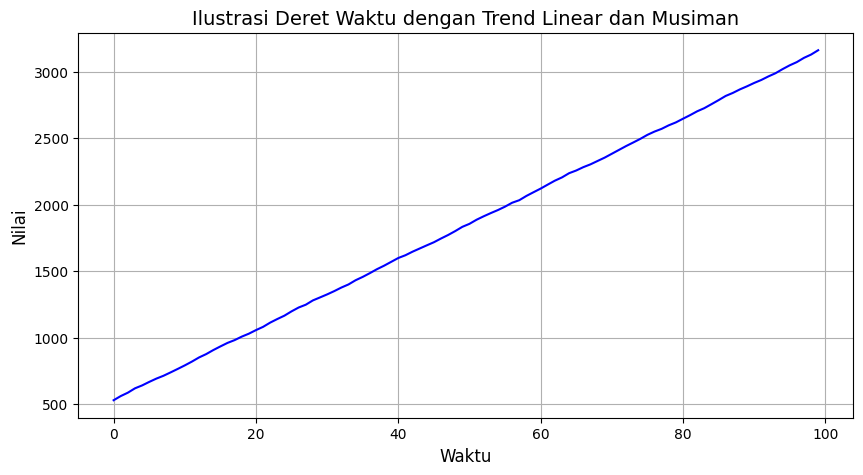

In [135]:
plt.figure(figsize=(10, 5))
plt.plot(x, series, color='b')
plt.xlabel('Waktu', fontsize=12)
plt.ylabel('Nilai', fontsize=12)
plt.title('Ilustrasi Deret Waktu dengan Trend Linear dan Musiman', fontsize=14)
plt.grid()
plt.show()

Untuk deret tersebut, dibutuhkan model yang mampu menangkap kecenderungan linear (tren) sekaligus kecenderungan musiman dalam deret. Salah satu model sederhana yang dapat digunakan adalah model regresi linear dengan variabel musiman.

In [136]:
# mengubah data menjadi format dataframe
df_mix = pd.DataFrame(series, columns=['Value'])

# mengekstrak komponen musiman dalam data
from statsmodels.tsa.deterministic import Seasonality
season= Seasonality(12, initial_period=1).in_sample(df_mix.index)
season.columns=['Januari','Februari','Maret','April','Mei','Juni','Juli','Agustus','September','Oktober','November','Desember']

In [137]:
season['period']=x

model_mix=sm.OLS(series,season).fit()

In [138]:
print(model_mix.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       1.000
Model:                            OLS   Adj. R-squared:                  1.000
Method:                 Least Squares   F-statistic:                 1.476e+06
Date:                Sat, 05 Sep 2026   Prob (F-statistic):          2.14e-225
Time:                        14:27:01   Log-Likelihood:                -194.69
No. Observations:                 100   AIC:                             415.4
Df Residuals:                      87   BIC:                             449.2
Df Model:                          12                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Januari      529.6632      0.677    781.894      0.0

Bagaimana cara menginterpretasikan nilai koefisien regresi yang diperoleh dalam model regresi tersebut?

Berdasarkan hasil regresi, koefisien period sebesar 26,5010 menunjukkan adanya kecenderungan linear positif. Setelah memperhitungkan pola musiman, setiap penambahan satu periode waktu menyebabkan nilai deret meningkat rata-rata sekitar 26,50 satuan. Nilai ini sangat dekat dengan parameter trend asli sebesar 26,5. Sementara itu, karena model menggunakan 12 dummy bulan tanpa intersep, koefisien setiap bulan menunjukkan level dasar untuk bulan tersebut, sedangkan perbedaan koefisien antarbulan menggambarkan pola musiman. Bulan Februari hingga Mei memiliki level musiman yang relatif lebih tinggi, sedangkan Agustus hingga Oktober cenderung lebih rendah. Dengan demikian, model mampu menangkap dua pola utama pada deret, yaitu kecenderungan linear meningkat dan pola musiman yang berulang setiap 12 periode.

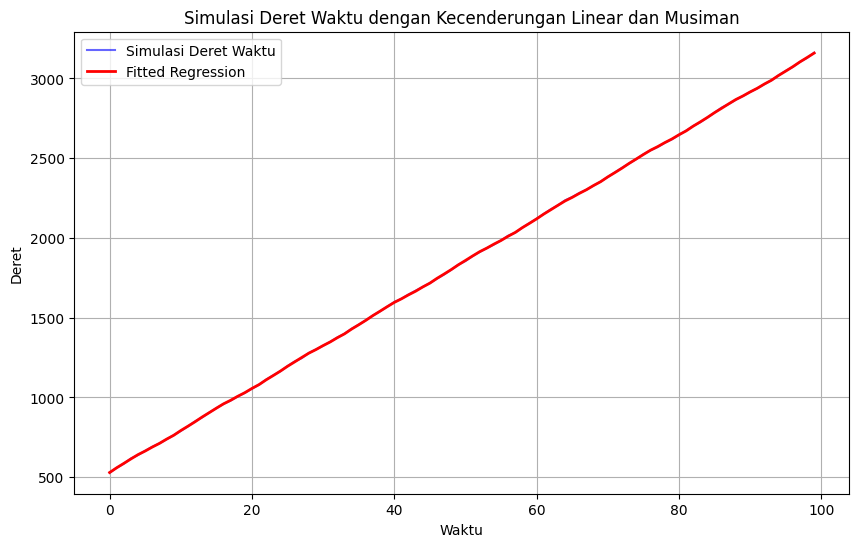

In [139]:
# Prediksi menggunakan model yang sudah dilatih
pred_mix = model_mix.predict(season)

# Plot hasil simulasi deret waktu dan regresi kuadratik
plt.figure(figsize=(10, 6))
plt.plot(x, series, label='Simulasi Deret Waktu', color='blue', alpha=0.6)
plt.plot(x, pred_mix, label='Fitted Regression', color='red', linewidth=2)
plt.title('Simulasi Deret Waktu dengan Kecenderungan Linear dan Musiman')
plt.xlabel('Waktu')
plt.ylabel('Deret')
plt.legend()
plt.grid(True)
plt.show()

Lakukan pengecekan asumsi model! Jelaskan apakah hasil menunjukkan ada pelanggaran asumsi dalam model!

Berdasarkan plot, garis hasil regresi hampir berhimpit dengan data simulasi, sehingga model tampak mampu menangkap kecenderungan linear dan pola musiman pada deret dengan sangat baik. Namun, kesesuaian antara nilai aktual dan fitted belum cukup untuk menyatakan bahwa seluruh asumsi regresi telah terpenuhi. Oleh karena itu, perlu dilakukan pemeriksaan residual meliputi asumsi normalitas, homoskedastisitas, dan tidak adanya autokorelasi residual.

In [ ]:
# uji asumsi model

In [140]:
from scipy import stats
from statsmodels.stats.diagnostic import het_breuschpagan, acorr_ljungbox
import statsmodels.api as sm

# Residual model linear + musiman
resid_mix = model_mix.resid

# ==================================================
# 1. UJI NORMALITAS SHAPIRO-WILK
# ==================================================
shapiro_stat, shapiro_p = stats.shapiro(resid_mix)

print("Shapiro-Wilk:")
print("Statistic =", shapiro_stat)
print("p-value =", shapiro_p)


# ==================================================
# 2. UJI HOMOSKEDASTISITAS BREUSCH-PAGAN
# ==================================================
# model_mix tidak memiliki intercept eksplisit,
# sehingga untuk BP dibuat X ekuivalen dengan konstanta:
# konstanta + 11 dummy bulan + period
X_bp_mix = sm.add_constant(
    pd.concat(
        [season.iloc[:, 1:12], season[["period"]]],
        axis=1
    )
)

bp_test = het_breuschpagan(resid_mix, X_bp_mix)

print("\nBreusch-Pagan:")
print("LM Statistic =", bp_test[0])
print("LM p-value =", bp_test[1])
print("F Statistic =", bp_test[2])
print("F p-value =", bp_test[3])


# ==================================================
# 3. UJI AUTOKORELASI LJUNG-BOX
# ==================================================
ljung_box = acorr_ljungbox(
    resid_mix,
    lags=[12],
    return_df=True
)

print("\nLjung-Box:")
print(ljung_box)

Shapiro-Wilk:
Statistic = 0.9901707023676554
p-value = 0.6783987807720115

Breusch-Pagan:
LM Statistic = 16.587266328740824
LM p-value = 0.16579347974102343
F Statistic = 1.4417184953717344
F p-value = 0.16281020740728191

Ljung-Box:
      lb_stat  lb_pvalue
12  18.502614    0.10126


Berdasarkan hasil pemeriksaan asumsi, model regresi yang memuat kecenderungan linear dan musiman tidak menunjukkan indikasi pelanggaran asumsi pada taraf signifikansi 5%. Uji Shapiro-Wilk menghasilkan p-value sebesar 0,6784 (>0,05), sehingga $(H_0)$ tidak ditolak. Dengan demikian, tidak terdapat bukti yang cukup untuk menyatakan bahwa residual menyimpang dari distribusi normal, sehingga asumsi normalitas dapat dianggap terpenuhi.

Uji Breusch-Pagan menghasilkan LM p-value sebesar 0,1658 dan F p-value sebesar 0,1628, yang keduanya lebih besar dari 0,05. Oleh karena itu, tidak terdapat indikasi heteroskedastisitas dan varians residual dapat dianggap relatif konstan, sehingga asumsi homoskedastisitas terpenuhi.

Uji Ljung-Box pada lag 12 menghasilkan p-value sebesar 0,1013 (>0,05), sehingga $(H_0)$ tidak ditolak. Hal ini menunjukkan bahwa tidak terdapat bukti yang cukup mengenai adanya autokorelasi residual hingga lag 12 pada taraf signifikansi 5%.

Dengan demikian, secara umum asumsi normalitas, homoskedastisitas, dan tidak adanya autokorelasi residual yang signifikan dapat dianggap terpenuhi. Oleh karena itu, model regresi sudah cukup sesuai untuk menggambarkan kecenderungan linear sekaligus pola musiman pada deret.

Saat melihat plot dari suatu deret, terkadang kita tidak yakin komponen apa saja yang ada dalam deret. Misalkan, apakah deret tidak memuat tren? apakah ada tren? apakah ada komponen musiman? Untuk memastikan komponen apa saja yang ada dalam suatu deret, dapat dilakukan dengan dekomposisi deret. Dekomposisi deret bertujuan menguraikan deret menjadi 3 komponen, yaitu tren, musiman, dan noise.

In [141]:
# Melakukan dekomposisi untuk deret simulasi kecenderungan linear
from statsmodels.tsa.seasonal import seasonal_decompose
result = seasonal_decompose(df['Value'], model='additive', period=12)

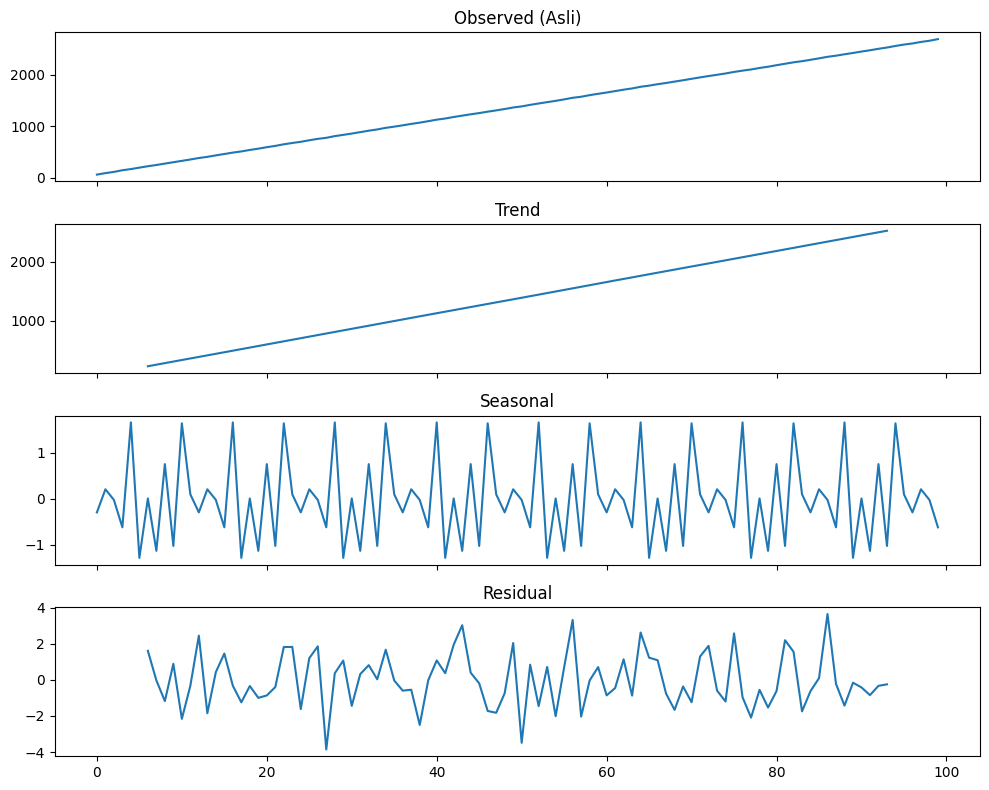

In [142]:
fig, axes = plt.subplots(4, 1, figsize=(10, 8), sharex=True)

result.observed.plot(ax=axes[0], title='Observed (Asli)')
result.trend.plot(ax=axes[1], title='Trend')
result.seasonal.plot(ax=axes[2], title='Seasonal')
result.resid.plot(ax=axes[3], title='Residual')

plt.tight_layout()
plt.show()

Bagaimana interpretasi hasil dekomposisi deret tersebut?

Berdasarkan hasil dekomposisi aditif, komponen Observed menunjukkan deret yang meningkat secara hampir linear dari waktu ke waktu. Komponen Trend juga memperlihatkan pola peningkatan linear yang sangat jelas dan menjadi komponen utama dalam deret.

Pada komponen Seasonal terlihat adanya fluktuasi yang berulang dengan amplitudo relatif kecil dibandingkan dengan trend. Namun, karena data simulasi awal hanya dibangkitkan dari kecenderungan linear dan noise tanpa komponen musiman, pola seasonal yang terbentuk kemungkinan merupakan hasil proses dekomposisi ketika periode 12 ditetapkan, bukan menunjukkan adanya pola musiman yang sebenarnya pada data.

Sementara itu, komponen Residual berfluktuasi secara acak di sekitar nol dan tidak menunjukkan pola tertentu yang jelas. Hal ini sesuai dengan adanya komponen noise pada proses pembangkitan data.

Dengan demikian, hasil dekomposisi menunjukkan bahwa trend linear merupakan komponen dominan, sedangkan komponen musiman yang teridentifikasi relatif kecil dan tidak dapat dianggap sebagai bukti adanya pola musiman yang nyata karena deret simulasi memang tidak dibangkitkan dengan komponen musiman.

In [143]:
# Melakukan dekomposisi untuk deret simulasi kecenderungan linear dan musiman
from statsmodels.tsa.seasonal import seasonal_decompose
result_mix = seasonal_decompose(df_mix['Value'], model='additive', period=12)

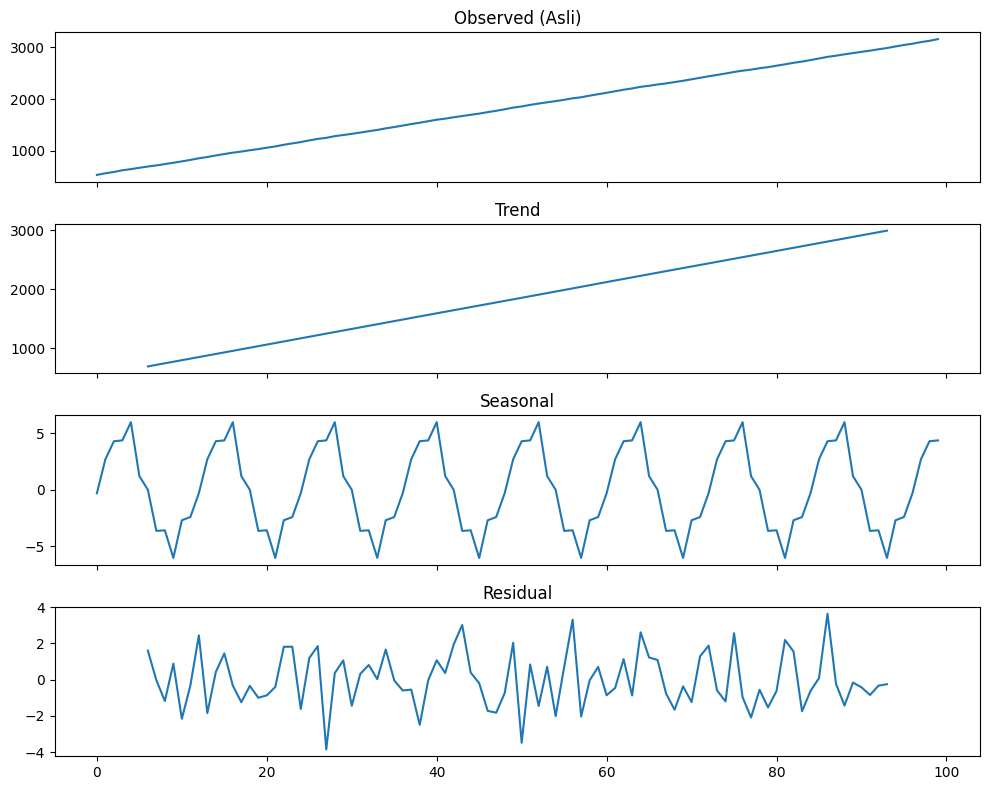

In [144]:
fig, axes = plt.subplots(4, 1, figsize=(10, 8), sharex=True)

result_mix.observed.plot(ax=axes[0], title='Observed (Asli)')
result_mix.trend.plot(ax=axes[1], title='Trend')
result_mix.seasonal.plot(ax=axes[2], title='Seasonal')
result_mix.resid.plot(ax=axes[3], title='Residual')

plt.tight_layout()
plt.show()


Bagaimana interpretasi hasil dekomposisi deret tersebut?

Berdasarkan hasil dekomposisi aditif, komponen Observed menunjukkan deret yang secara umum meningkat dari waktu ke waktu. Pola peningkatan ini terutama dijelaskan oleh komponen Trend, yang memperlihatkan kecenderungan linear positif dan relatif konsisten.

Komponen Seasonal menunjukkan pola naik-turun yang berulang secara teratur setiap 12 periode, dengan amplitudo yang relatif tetap. Hal ini menunjukkan adanya pola musiman yang konsisten sepanjang deret. Meskipun pada plot observed pola musiman terlihat relatif kecil dibandingkan trend, dekomposisi mampu memisahkan komponen musiman tersebut dengan jelas.

Sementara itu, komponen Residual berfluktuasi secara acak di sekitar nol dan tidak menunjukkan pola sistematis yang jelas. Hal ini menunjukkan bahwa setelah komponen trend dan musiman dipisahkan, variasi yang tersisa sebagian besar merupakan komponen acak atau noise.

Dengan demikian, hasil dekomposisi sesuai dengan struktur data simulasi, yaitu terdiri atas kecenderungan linear yang meningkat, pola musiman dengan periode 12, dan komponen acak.

Ketika melakukan dekoposisi deret, perlu diperhatikan bahwa terdapat 2 jenis model untuk dekomposisi, yaitu model `Aditif` dan `multiplikatif`.

- Model `aditif` digunakan jika ragam deret relatif konstan atau kecil

- Model `multiplikatif` digunakan jika ragam deret besar

In [145]:
# ilustrasi untuk deret multiplikatif
# Parameter
np.random.seed(1053)
n = 100  # Jumlah titik data
x = np.arange(n)

# Komponen trend linear
a, b = 0.05*53, 10*53 #(intersep dan slope)
trend = a * x + b

# Komponen musiman (sinusoidal)
seasonality = 1+ 0.5 * np.sin(2 * np.pi * x / 12)

# Noise acak
noise = np.random.normal(scale=0.2, size=n)

# Gabungan semua komponen
series_multi = trend*seasonality + noise

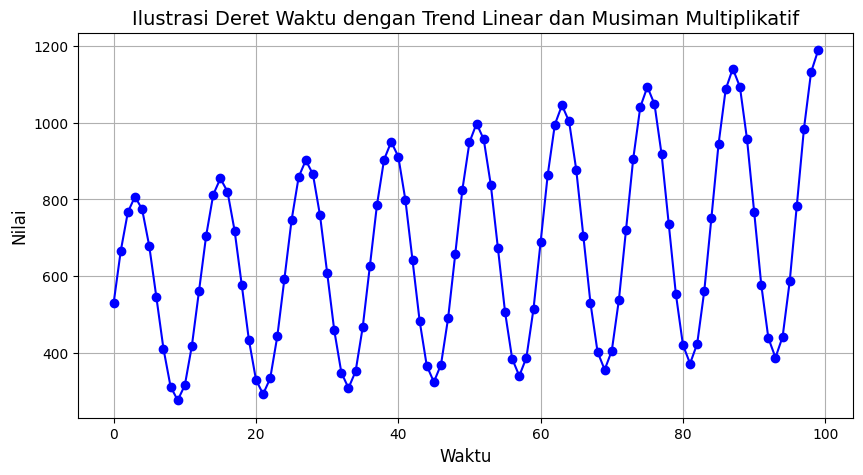

In [146]:
plt.figure(figsize=(10, 5))
plt.plot(x, series_multi, color='b', marker='o')
plt.xlabel('Waktu', fontsize=12)
plt.ylabel('Nilai', fontsize=12)
plt.title('Ilustrasi Deret Waktu dengan Trend Linear dan Musiman Multiplikatif', fontsize=14)
plt.grid()
plt.show()

Dekomposisi dengan model multiplikatif hanya bisa dilakukan untuk deret dengan nilai >0, sehingga jika deret memiliki nilai 0 atau negatif maka deret perlu ditransformasi.

In [147]:
#  Dekomposisi dengan model multiplikatif
# mengubah data menjadi format dataframe
df_multi = pd.DataFrame(series_multi, columns=['Value'])

from statsmodels.tsa.seasonal import seasonal_decompose
result_multi = seasonal_decompose(df_multi['Value'], model='multiplicative', period=12)

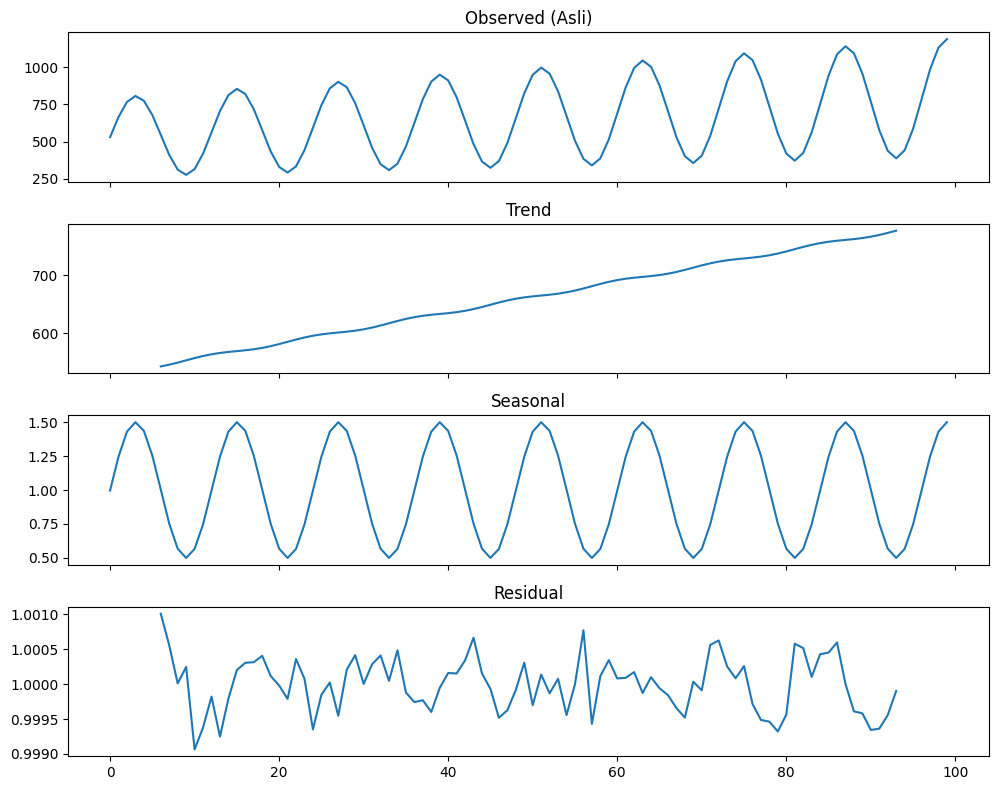

In [148]:
# Plot hasil dekomposisi
fig, axes = plt.subplots(4, 1, figsize=(10, 8), sharex=True)
result_multi.observed.plot(ax=axes[0], title='Observed (Asli)')
result_multi.trend.plot(ax=axes[1], title='Trend')
result_multi.seasonal.plot(ax=axes[2], title='Seasonal')
result_multi.resid.plot(ax=axes[3], title='Residual')

plt.tight_layout()
plt.show()

Bagaimana Anda menginterpretasikan plot hasil dekomposisi tersebut?

Berdasarkan hasil dekomposisi multiplikatif, komponen Observed menunjukkan deret dengan kecenderungan meningkat disertai pola naik-turun yang berulang setiap 12 periode. Besarnya fluktuasi musiman juga semakin besar ketika level deret meningkat, sehingga karakteristik tersebut sesuai dengan pola multiplikatif.

Komponen Trend menunjukkan peningkatan level deret secara bertahap dari waktu ke waktu. Komponen Seasonal berfluktuasi di sekitar nilai 1 dan berfungsi sebagai faktor pengali terhadap trend. Nilai seasonal di atas 1 menunjukkan bahwa nilai deret berada di atas level trend akibat pengaruh musiman, sedangkan nilai di bawah 1 menunjukkan bahwa nilai deret berada di bawah level trend. Misalnya, faktor sekitar 1,5 berarti nilai akibat pola musiman sekitar 1,5 kali level trend, sedangkan faktor sekitar 0,5 berarti sekitar setengah dari level trend.

Komponen Residual berfluktuasi sangat dekat dengan nilai 1 dan tidak menunjukkan pola sistematis yang jelas. Hal tersebut menunjukkan bahwa sebagian besar struktur deret telah dapat dijelaskan oleh komponen trend dan musiman, sedangkan variasi yang tersisa relatif kecil dan bersifat acak.

In [149]:
# Parameter
np.random.seed(1053)
n = 100  # Jumlah titik data
x = np.arange(n)

# Hanya noise acak tanpa trend atau musiman
noise = np.random.normal(loc=10, scale=2, size=n)  # Nilai acak sekitar 10

# Buat DataFrame untuk regresi
df = pd.DataFrame({'Time': x, 'Series': noise})
df['Time'] = pd.to_datetime(df['Time'], unit='D')  # Konversi ke format waktu
df.set_index('Time', inplace=True)

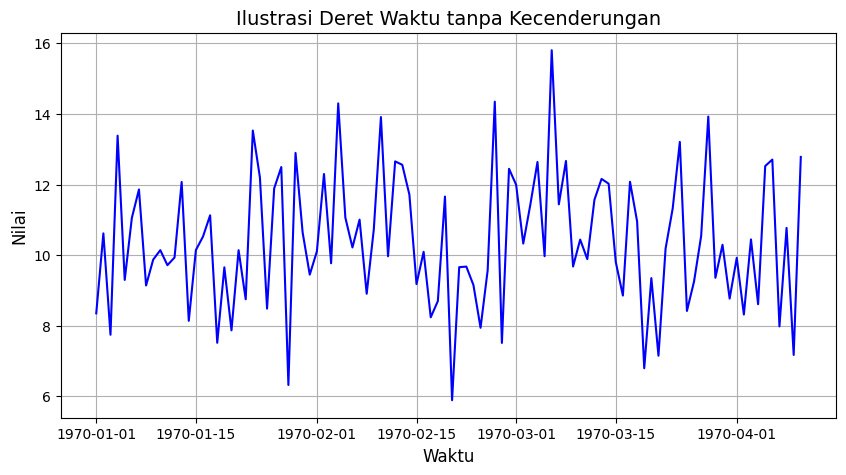

In [150]:
plt.figure(figsize=(10, 5))
plt.plot(df.index, df['Series'], color='b')
plt.xlabel('Waktu', fontsize=12)
plt.ylabel('Nilai', fontsize=12)
plt.title('Ilustrasi Deret Waktu tanpa Kecenderungan', fontsize=14)
plt.grid()
plt.show()

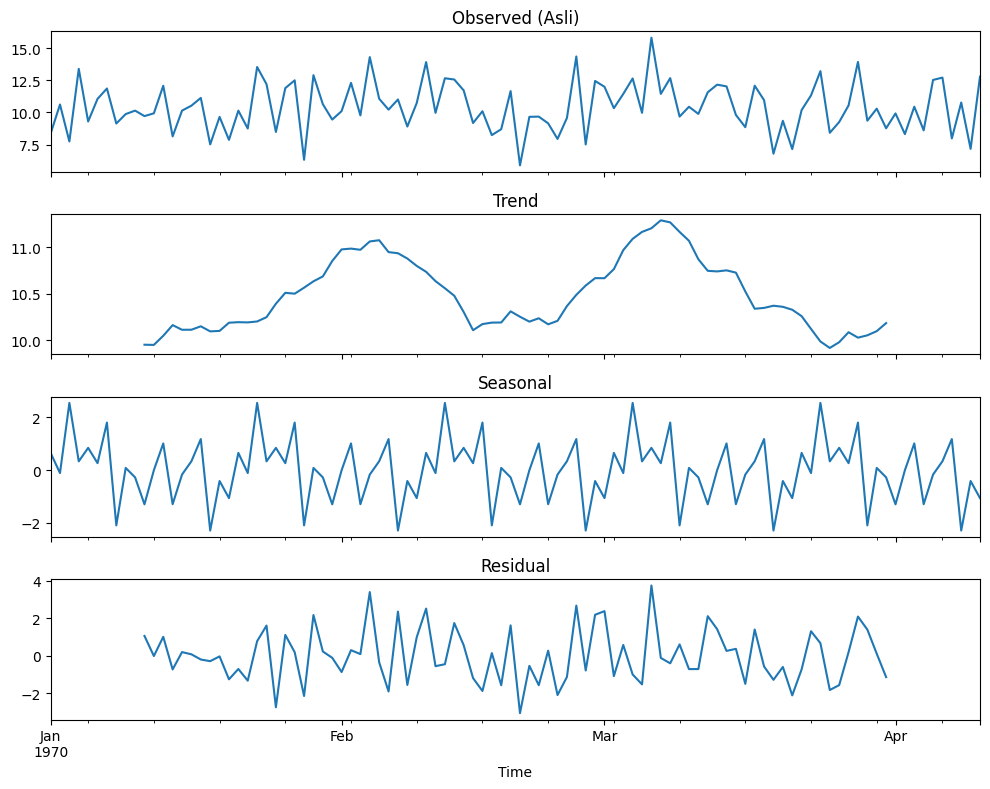

In [151]:
# Lakukan dekomposisi dengan model aditif
result = seasonal_decompose(df['Series'], model='additive', period=20)

# Plot hasil dekomposisi
fig, axes = plt.subplots(4, 1, figsize=(10, 8), sharex=True)
result.observed.plot(ax=axes[0], title='Observed (Asli)')
result.trend.plot(ax=axes[1], title='Trend')
result.seasonal.plot(ax=axes[2], title='Seasonal')
result.resid.plot(ax=axes[3], title='Residual')

plt.tight_layout()
plt.show()

Bagaimana interpretasi dari plot tersebut?

Berdasarkan plot Observed, nilai deret berfluktuasi secara acak di sekitar rata-rata yang relatif konstan, yaitu sekitar 10, dan tidak terlihat kecenderungan meningkat atau menurun maupun pola musiman yang jelas. Hal ini sesuai dengan proses simulasi karena data hanya dibangkitkan dari noise acak dengan rata-rata 10 dan simpangan baku 2.

Komponen Trend hasil dekomposisi menunjukkan sedikit perubahan level dari waktu ke waktu. Namun, perubahan tersebut tidak dapat langsung diinterpretasikan sebagai trend yang sebenarnya karena data simulasi memang tidak dibangkitkan dengan komponen trend. Pola tersebut merupakan hasil proses pemulusan yang dilakukan oleh metode dekomposisi terhadap fluktuasi acak.

Komponen Seasonal juga menunjukkan pola yang berulang karena pada proses dekomposisi telah ditetapkan period=20. Namun, karena proses pembangkitan data tidak mengandung komponen musiman, pola seasonal tersebut tidak dapat dianggap sebagai bukti adanya pola musiman yang sebenarnya.

Komponen Residual berfluktuasi secara acak di sekitar nol dan tidak menunjukkan pola sistematis yang jelas. Dengan demikian, karakteristik utama deret adalah fluktuasi acak di sekitar rata-rata yang relatif konstan tanpa trend dan pola musiman yang nyata.